In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Carbon_Emission_Project.csv')
df 

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index,Carbon_Emissions_tCO2
0,Paper,2021,3272.11,4419.06,66550.22,44.09,4740,1.92,9200.38
1,Textile,2010,24265.34,6363.40,51754.30,3.84,1961,1.18,24623.68
2,Chemical,2015,27000.86,1299.17,72847.38,23.92,6690,1.86,13828.56
3,Paper,2020,8871.68,2799.04,33309.77,5.17,2627,3.87,9478.94
4,Power,2002,16461.27,5125.72,63012.39,21.66,2967,1.28,17664.16
...,...,...,...,...,...,...,...,...,...
6495,Automobile,2007,33872.78,7873.90,40457.78,48.98,6530,2.90,30258.13
6496,Steel,2009,7106.71,5540.28,9120.60,2.76,7906,2.34,14995.44
6497,Textile,2018,40389.96,6832.56,53149.75,42.55,7969,2.31,31227.91
6498,Cement,2002,49491.96,9389.95,84120.91,43.22,4132,9.58,40050.87


In [2]:
df.shape

(6500, 9)

In [3]:
df.head()

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index,Carbon_Emissions_tCO2
0,Paper,2021,3272.11,4419.06,66550.22,44.09,4740,1.92,9200.38
1,Textile,2010,24265.34,6363.40,51754.30,3.84,1961,1.18,24623.68
2,Chemical,2015,27000.86,1299.17,72847.38,23.92,6690,1.86,13828.56
3,Paper,2020,8871.68,2799.04,33309.77,5.17,2627,3.87,9478.94
4,Power,2002,16461.27,5125.72,63012.39,21.66,2967,1.28,17664.16


In [4]:
df.tail()

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index,Carbon_Emissions_tCO2
6495,Automobile,2007,33872.78,7873.90,40457.78,48.98,6530,2.90,30258.13
6496,Steel,2009,7106.71,5540.28,9120.60,2.76,7906,2.34,14995.44
6497,Textile,2018,40389.96,6832.56,53149.75,42.55,7969,2.31,31227.91
6498,Cement,2002,49491.96,9389.95,84120.91,43.22,4132,9.58,40050.87
6499,Automobile,2023,19180.69,6419.88,12778.59,12.84,4538,7.24,21372.65


In [5]:
df.columns

Index(['Industry_Type', 'Year', 'Energy_Consumption_MWh',
       'Fuel_Consumption_Tons', 'Production_Output_Tons',
       'Renewable_Energy_Percentage', 'Operating_Hours',
       'Emission_Control_Index', 'Carbon_Emissions_tCO2'],
      dtype='object')

In [6]:
df.dtypes

Industry_Type                   object
Year                             int64
Energy_Consumption_MWh         float64
Fuel_Consumption_Tons          float64
Production_Output_Tons         float64
Renewable_Energy_Percentage    float64
Operating_Hours                  int64
Emission_Control_Index         float64
Carbon_Emissions_tCO2          float64
dtype: object

In [7]:
df.isnull().sum()

Industry_Type                  0
Year                           0
Energy_Consumption_MWh         0
Fuel_Consumption_Tons          0
Production_Output_Tons         0
Renewable_Energy_Percentage    0
Operating_Hours                0
Emission_Control_Index         0
Carbon_Emissions_tCO2          0
dtype: int64

In [8]:
df1 = df['Industry_Type'].value_counts()
df1


Industry_Type
Steel         971
Textile       955
Chemical      945
Automobile    924
Power         918
Cement        895
Paper         892
Name: count, dtype: int64

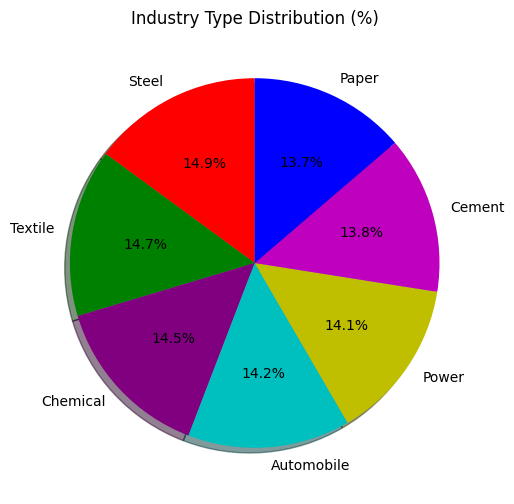

In [9]:
colors = ('r','g','purple','c','y','m','b')

plt.figure(figsize=(6,6))
plt.pie(
    df1.values,
    labels=df1.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title("Industry Type Distribution (%)")
plt.show()


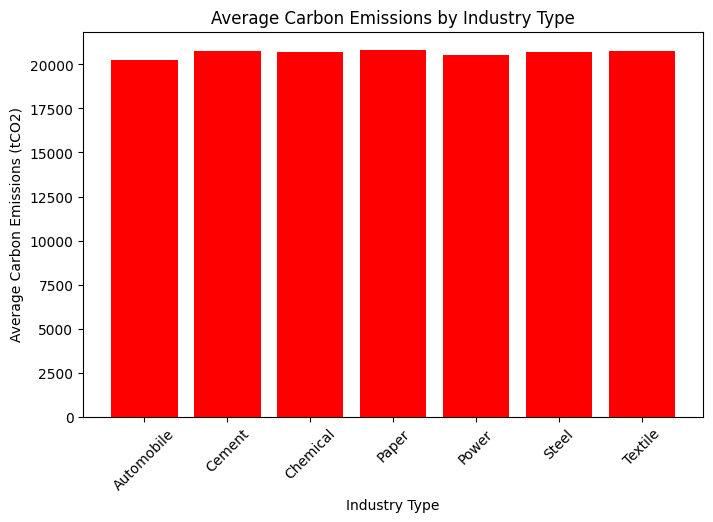

In [10]:
# Carbon emissions by industry

industry_emission = df.groupby("Industry_Type")["Carbon_Emissions_tCO2"].mean()
plt.figure(figsize=(8,5))
plt.bar(industry_emission.index, industry_emission.values, color='red')
plt.xticks(rotation=45)
plt.xlabel("Industry Type")
plt.ylabel("Average Carbon Emissions (tCO2)")
plt.title("Average Carbon Emissions by Industry Type")
plt.show()


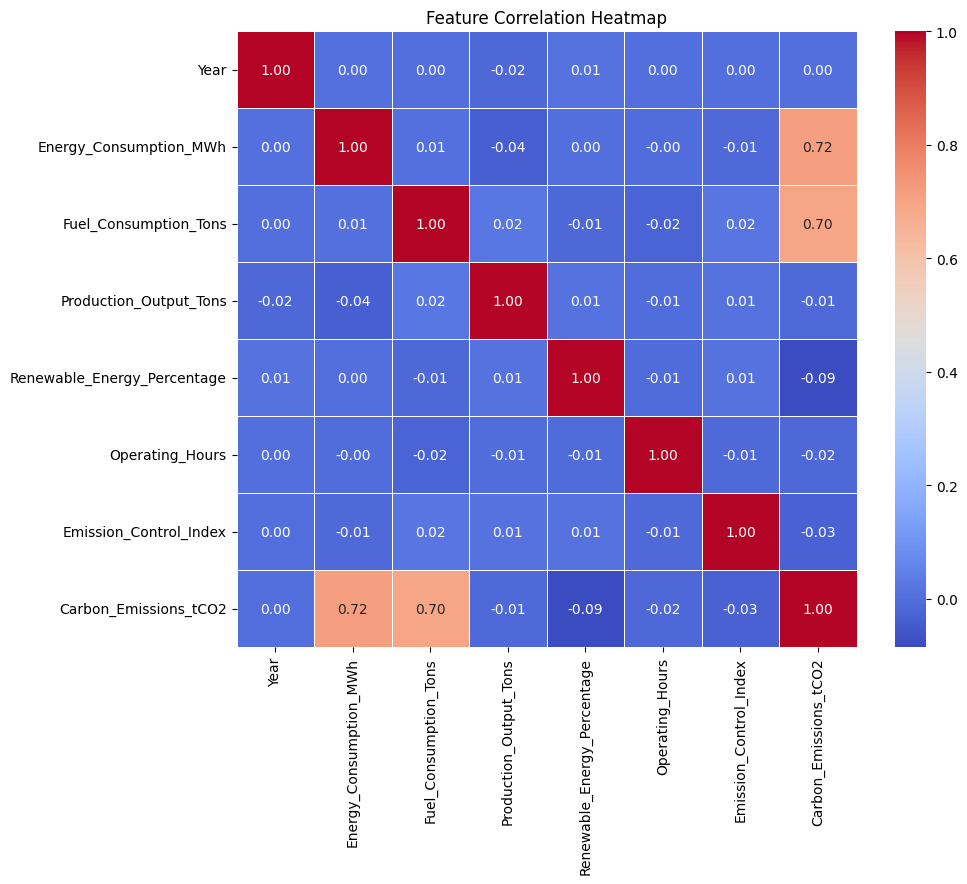

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
df['Industry_Type'] = lab.fit_transform(df['Industry_Type'])
df

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index,Carbon_Emissions_tCO2
0,3,2021,3272.11,4419.06,66550.22,44.09,4740,1.92,9200.38
1,6,2010,24265.34,6363.40,51754.30,3.84,1961,1.18,24623.68
2,2,2015,27000.86,1299.17,72847.38,23.92,6690,1.86,13828.56
3,3,2020,8871.68,2799.04,33309.77,5.17,2627,3.87,9478.94
4,4,2002,16461.27,5125.72,63012.39,21.66,2967,1.28,17664.16
...,...,...,...,...,...,...,...,...,...
6495,0,2007,33872.78,7873.90,40457.78,48.98,6530,2.90,30258.13
6496,5,2009,7106.71,5540.28,9120.60,2.76,7906,2.34,14995.44
6497,6,2018,40389.96,6832.56,53149.75,42.55,7969,2.31,31227.91
6498,1,2002,49491.96,9389.95,84120.91,43.22,4132,9.58,40050.87


In [13]:
X = df.drop('Carbon_Emissions_tCO2', axis=1)
y = df['Carbon_Emissions_tCO2']

In [14]:
X

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index
0,3,2021,3272.11,4419.06,66550.22,44.09,4740,1.92
1,6,2010,24265.34,6363.40,51754.30,3.84,1961,1.18
2,2,2015,27000.86,1299.17,72847.38,23.92,6690,1.86
3,3,2020,8871.68,2799.04,33309.77,5.17,2627,3.87
4,4,2002,16461.27,5125.72,63012.39,21.66,2967,1.28
...,...,...,...,...,...,...,...,...
6495,0,2007,33872.78,7873.90,40457.78,48.98,6530,2.90
6496,5,2009,7106.71,5540.28,9120.60,2.76,7906,2.34
6497,6,2018,40389.96,6832.56,53149.75,42.55,7969,2.31
6498,1,2002,49491.96,9389.95,84120.91,43.22,4132,9.58


In [15]:
y

0        9200.38
1       24623.68
2       13828.56
3        9478.94
4       17664.16
          ...   
6495    30258.13
6496    14995.44
6497    31227.91
6498    40050.87
6499    21372.65
Name: Carbon_Emissions_tCO2, Length: 6500, dtype: float64

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
x_train

,Industry_Type,Year,Energy_Consumption_MWh,Fuel_Consumption_Tons,Production_Output_Tons,Renewable_Energy_Percentage,Operating_Hours,Emission_Control_Index
889,1,2019,7110.38,1270.56,90640.63,3.74,6128,5.80
4385,5,2001,14437.93,4664.00,63045.27,47.34,3486,6.56
4919,0,2002,30796.46,6444.64,4858.04,40.39,3235,1.57
4794,5,2021,10241.11,2098.86,21538.60,39.27,4621,4.36
5438,5,2004,12996.15,9673.19,37670.98,8.87,4474,8.09
...,...,...,...,...,...,...,...,...
3772,2,2023,44655.49,7500.53,77625.21,4.45,2371,9.54
5191,3,2018,19091.65,939.08,90249.56,53.75,4946,4.02
5226,1,2009,10495.94,6047.07,73776.60,26.25,2082,9.62
5390,0,2022,9110.42,7498.29,58503.44,44.51,1207,3.01


In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)


In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)


Linear Regression RMSE: 0.0029376445980254366


In [20]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 436.0792569723706


In [22]:
# MAPE
from sklearn.metrics import mean_absolute_percentage_error
print("Linear Regression MAPE  :", mean_absolute_percentage_error(y_test, y_pred_lr) * 100)

Linear Regression MAPE  : 2.3120270576242847e-05


In [23]:
# MAPE
from sklearn.metrics import mean_absolute_percentage_error
print("Random Forest MAPE :", mean_absolute_percentage_error(y_test, y_pred_rf) * 100)

Random Forest MAPE : 3.1882918379923035


In [24]:
if rmse_rf < rmse_lr:
    print("Random Forest performs better")
else:
    print("Linear Regression performs better")


Linear Regression performs better


In [25]:
from sklearn.metrics import r2_score
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression R2 Score:", r2_lr)


Linear Regression R2 Score: 0.9999999999998932


In [26]:
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2 Score:", r2_rf)


Random Forest R2 Score: 0.9976454338721412


In [27]:
if r2_rf > r2_lr:
    print("Random Forest performs better based on R2 score")
else:
    print("Linear Regression performs better based on R2 score")


Linear Regression performs better based on R2 score
